### Clasificación y Optimización de Hiperparámetros (Core)
#### Objetivo: Implementar un pipeline completo de machine learning para un problema de clasificación utilizando técnicas de preprocesamiento, modelado, y optimización de hiperparámetros. Enfocar especialmente en la limpieza de datos y la optimización utilizando GridSearchCV y RandomizedSearchCV.



### Dataset: Medical Cost Personal Dataset


#### Descripción del Dataset: El dataset de costos médicos personales contiene información sobre varios factores que afectan los costos de seguros médicos, como la edad, el sexo, el índice de masa corporal, y el hábito de fumar. Este dataset es ideal para practicar técnicas de preprocesamiento y optimización de modelos debido a la presencia de datos sucios y variables tanto categóricas como numéricas.

### 1.- Carga y Exploración Inicial de Datos:
- **1.1.- Cargar el dataset desde Kaggle.**

In [255]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV , cross_val_score, KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier,GradientBoostingRegressor
from lightgbm import LGBMClassifier
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, classification_report,ConfusionMatrixDisplay, f1_score, precision_score, recall_score ,roc_auc_score , roc_curve , auc, confusion_matrix
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import joblib



In [256]:
df = pd.read_csv('data/insurance.csv')




- **1.2.- Realizar una exploración inicial para entender la estructura del dataset y las características disponibles.**


In [257]:
print("\n dimensiones")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}\n")

print("\n primeras 5 filas\n")
display(df.head(10))

# los ultimos 5 registros
print("ultimos 5 registros : ")
display(df.tail())


print("\n nombres de las columnas \n")
display(df.columns.tolist())

print("\n tipos de datos \n")
print(df.info())

print("\n estadisticas descriptivas \n")
display(df.describe())

print("\n tipo columnas \n")
display(df.dtypes)



 dimensiones
Filas: 1338, Columnas: 7


 primeras 5 filas



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


ultimos 5 registros : 


,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603



 nombres de las columnas 



['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


 tipos de datos 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

 estadisticas descriptivas 



,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010



 tipo columnas 



age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

- **1.3.- Identificar y documentar los valores faltantes y outliers en el dataset.**

| Columna   | Tipo    | Descripción                                      |
|-----------|---------|--------------------------------------------------|
| age       | int64   | Edad del asegurado (en años)                     |
| sex       | str  | Género del asegurado (male / female)             |
| bmi       | float64 | Índice de Masa Corporal (Body Mass Index)        |
| children  | int64   | Número de hijos/dependientes cubiertos...        |
| smoker    | str  | Indica si la persona es fumadora (yes / no)      |
| region    | str  | Región de residencia...                          |
| charges   | float64 | Costo de los cargos médicos anuales...           |

In [258]:

print(" - Identificar y solucionar cualquier inconsistencia en los valores categóricos (ejemplo: cat, Cat, cats).")

for col in df.columns:
    valores_unicos = df[col].unique()
    print(f"• {col:20} -> {len(valores_unicos)} únicos")
    print(f"  Lista de Valores :   {valores_unicos}\n")

# verificar datos nulos en el dataframe
print("\nDatos nulos por columna : \n")
print(df.isnull().sum())
print("\nDatos nulos totales : ", df.isnull().sum().sum())

print("\nNo se encuentran valores nulos en el dataset, por lo que no es necesario realizar imputación de datos.")

df.replace(np.nan, 0, inplace=True)      

 - Identificar y solucionar cualquier inconsistencia en los valores categóricos (ejemplo: cat, Cat, cats).
• age                  -> 47 únicos
  Lista de Valores :   [19 18 28 33 32 31 46 37 60 25 62 23 56 27 52 30 34 59 63 55 22 26 35 24
 41 38 36 21 48 40 58 53 43 64 20 61 44 57 29 45 54 49 47 51 42 50 39]

• sex                  -> 2 únicos
  Lista de Valores :   ['female' 'male']

• bmi                  -> 548 únicos
  Lista de Valores :   [27.9   33.77  33.    22.705 28.88  25.74  33.44  27.74  29.83  25.84
 26.22  26.29  34.4   39.82  42.13  24.6   30.78  23.845 40.3   35.3
 36.005 32.4   34.1   31.92  28.025 27.72  23.085 32.775 17.385 36.3
 35.6   26.315 28.6   28.31  36.4   20.425 32.965 20.8   36.67  39.9
 26.6   36.63  21.78  30.8   37.05  37.3   38.665 34.77  24.53  35.2
 35.625 33.63  28.    34.43  28.69  36.955 31.825 31.68  22.88  37.335
 27.36  33.66  24.7   25.935 22.42  28.9   39.1   36.19  23.98  24.75
 28.5   28.1   32.01  27.4   34.01  29.59  35.53  39.805 26.885 3

In [259]:
# deteccion de outliarns en el dataframe
print("\n deteccion de outliarns en el dataframe.\n")
# columnas numericas
colum_numericas = [col for col in df if df[col].dtype in ['int64', 'float64']]

print("\n columnas numericas : ", colum_numericas)

# columnas categoricas
colum_categoricas = [col for col in df if df[col].dtype == 'object']

print("\n columnas categoricas :  ", colum_categoricas, "\n")

def deteccion_outliers(df_e, column):
    Q1 = df_e[column].quantile(0.25)
    Q3 = df_e[column].quantile(0.75)
    IQR = Q3 - Q1
    limit_inf = Q1 - 1.5 * IQR
    limit_sup = Q3 + 1.5 * IQR
    outliers = df_e[(df_e[column] < limit_inf) | (df_e[column] > limit_sup)]
    return outliers, limit_inf, limit_sup

def remover_outliers(df_e, column):
    Q1 = df_e[column].quantile(0.25)
    Q3 = df_e[column].quantile(0.75)
    IQR = Q3 - Q1
    limit_inf = Q1 - 1.5 * IQR
    limit_sup = Q3 + 1.5 * IQR
    df_out = df_e[(df_e[column] >= limit_inf) & (df_e[column] <= limit_sup)]
    return df_out

def mostrar_correccion_outliers(df_lim, column, arr_outliers):
   # print("arr_outliers", arr_outliers[column])

    existe = any(arr== column for arr in arr_outliers)
    #print("existe : ", existe)
    if existe: 
        outliers = df_lim[(df_lim[column] < arr_outliers[column]['lower']) | (df_lim[column] > arr_outliers[column]['upper'])]
 #       print(f"outliers {df_lim[column]} " )
 #       display("mostrar outliers", outliers)
        count = len(outliers) # cuenta la cantidad de outliers encontrados en la columna
        print(f"{column:18} -> cantidad de outliers = {count:3} | limites : [{arr_outliers[column]['lower']:,.2f}, {arr_outliers[column]['upper']:,.2f}]")

arr_outliers = {}

for col in colum_numericas:
        outliers, lower, upper = deteccion_outliers(df, col)
        # Guardas los valores

        count = len(outliers) # cuenta la cantidad de outliers encontrados en la columna
        if count > 0:
            print(f"{col:18} -> cantidad de outliers = {count:3} | limites : [{lower:,.2f}, {upper:,.2f}]")
            nombre_outlier = col
            arr_outliers.update({nombre_outlier: {'upper': upper, 'lower': lower}})



print("\nCorrección de outliers")

df_clean = df.copy()

for col in colum_numericas:            
    df_clean = remover_outliers(df_clean, col)



print("\n mostrar corrección de outlierns. \n ")
#display('df_limpio',df_limpio['length'])
#display(arr_outliers)
for col in colum_numericas:
    #print(f"columna : {col} ")
    mostrar_correccion_outliers(df_clean, col, arr_outliers)


 deteccion de outliarns en el dataframe.


 columnas numericas :  ['age', 'bmi', 'children', 'charges']

 columnas categoricas :   ['sex', 'smoker', 'region'] 

bmi                -> cantidad de outliers =   9 | limites : [13.70, 47.29]
charges            -> cantidad de outliers = 139 | limites : [-13,109.15, 34,489.35]

Corrección de outliers

 mostrar corrección de outlierns. 
 
bmi                -> cantidad de outliers =   0 | limites : [13.70, 47.29]
charges            -> cantidad de outliers =   0 | limites : [-13,109.15, 34,489.35]


### 2.- Preprocesamiento de Datos:
- **2.1.- Imputar valores faltantes utilizando técnicas adecuadas (media, mediana, moda, imputación avanzada).**


In [260]:
# verificar datos nulos en el dataframe
print("\nDatos nulos por columna : \n")
print(df.isnull().sum())
print("\nDatos nulos totales : ", df.isnull().sum().sum())

print("\nNo se encuentran valores nulos en el dataset, por lo que no es necesario realizar imputación de datos.")






Datos nulos por columna : 

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Datos nulos totales :  0

No se encuentran valores nulos en el dataset, por lo que no es necesario realizar imputación de datos.


In [261]:
# Verificar tipos de datos
restipo = []
res = ""
for columna in df.columns:
        # Sugerencias de tipo
    if df[columna].dtype == 'object':
        res = "Posible columna categórica o fecha"
    else:
       res = "Tipo numérico correcto"   


    restipo.append({
        'Columna': columna,
        'Tipo actual': df[columna].dtype,
        'Valores únicos': df[columna].nunique(),
        'Tipo' : res,
        'Ejemplos': df[columna].dropna().unique()[:5].tolist()
    })
        
results_df = pd.DataFrame(restipo)
display(results_df.sort_values(by='Columna', ascending=False))


,Columna,Tipo actual,Valores únicos,Tipo,Ejemplos
4,smoker,object,2,Posible columna categórica o fecha,"[yes, no]"
1,sex,object,2,Posible columna categórica o fecha,"[female, male]"
5,region,object,4,Posible columna categórica o fecha,"[southwest, southeast, northwest, northeast]"
3,children,int64,6,Tipo numérico correcto,"[0, 1, 3, 2, 5]"
6,charges,float64,1337,Tipo numérico correcto,"[16884.924, 1725.5523, 4449.462, 21984.47061, ..."
2,bmi,float64,548,Tipo numérico correcto,"[27.9, 33.77, 33.0, 22.705, 28.88]"
0,age,int64,47,Tipo numérico correcto,"[19, 18, 28, 33, 32]"


- **Visualizaciones univariadas y multivariadas:**

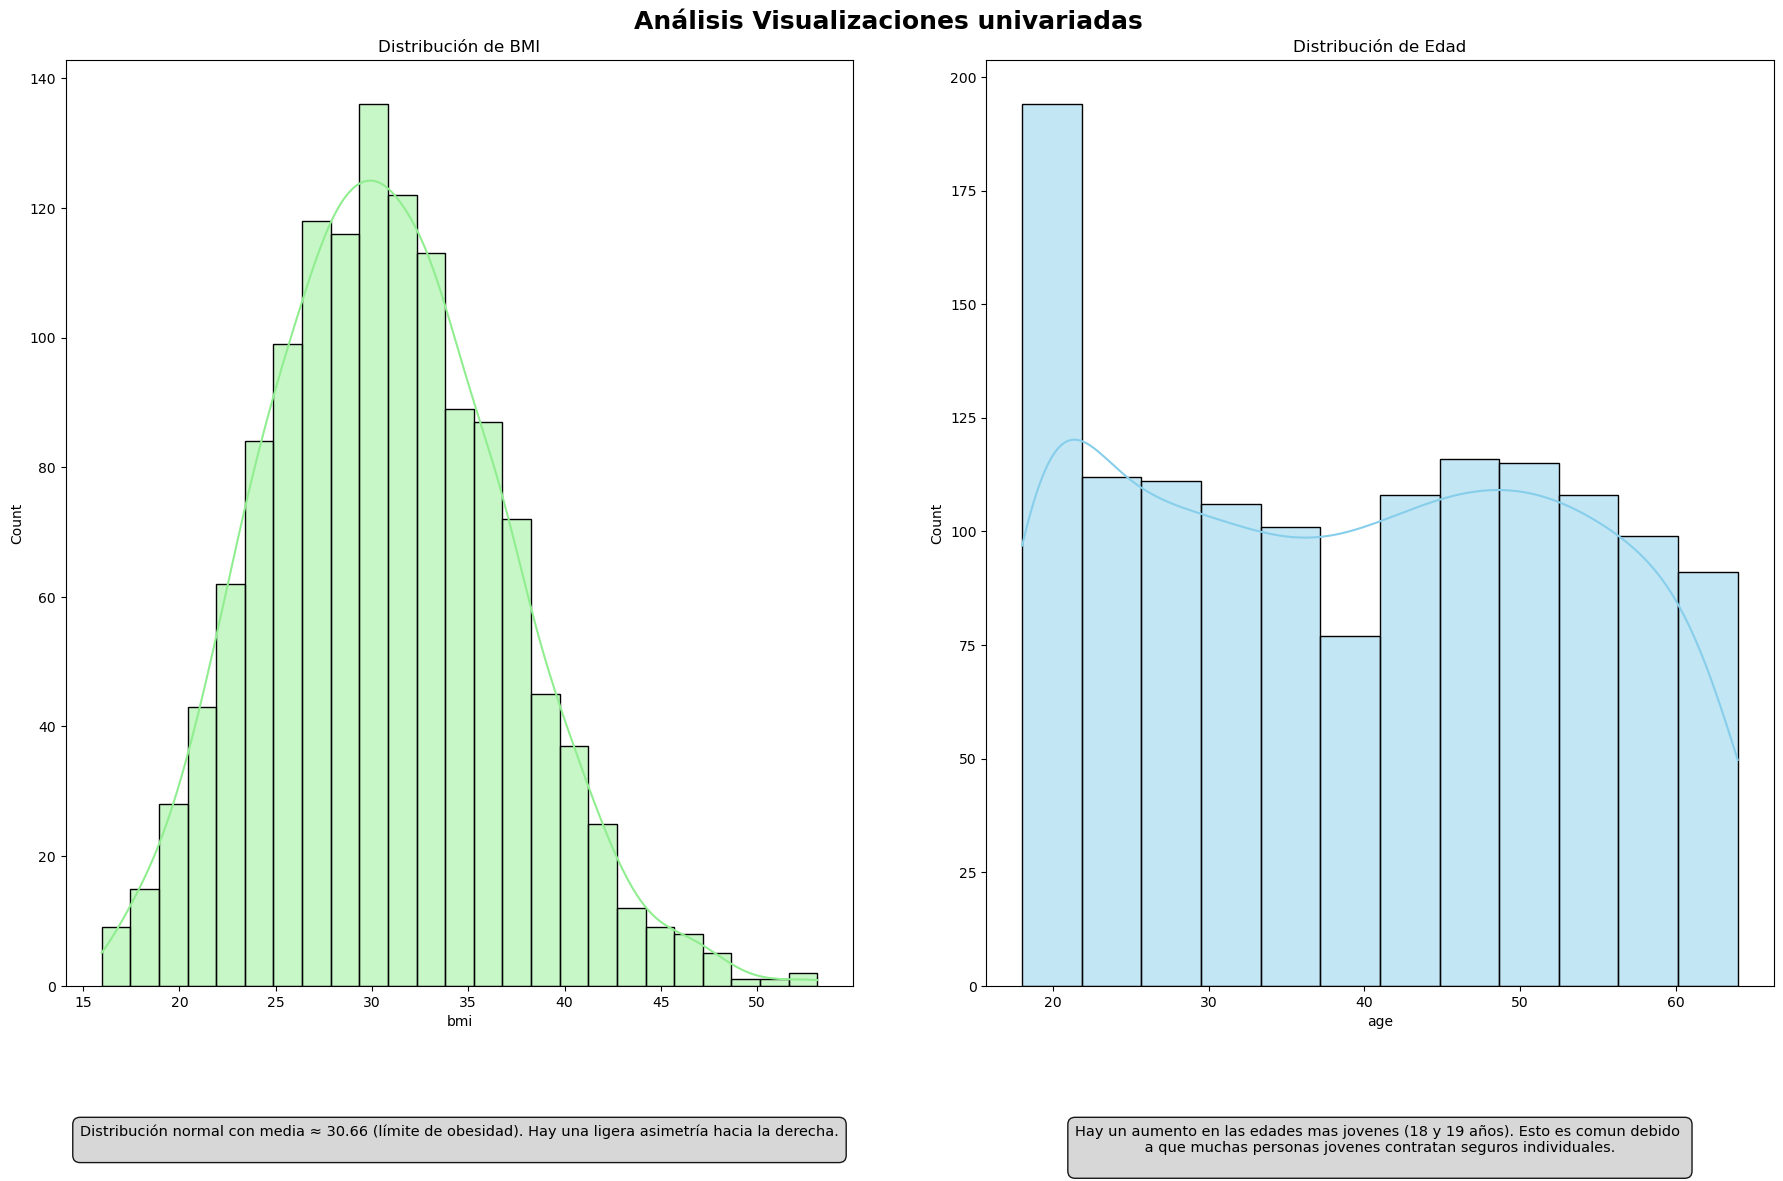

In [262]:

fig, axes = plt.subplots(1, 2, figsize=(18, 12))
fig.suptitle('Análisis Visualizaciones univariadas', fontsize=18, fontweight='bold')


sns.histplot(df['bmi'], kde=True, ax=axes[0], color='lightgreen')
axes[0].set_title('Distribución de BMI')
axes[0].text(0.5, -0.15,  
        "Distribución normal con media ≈ 30.66 (límite de obesidad). Hay una ligera asimetría hacia la derecha.\n", 

        transform=axes[0].transAxes, ha='center', va='top', fontsize=10.5, 
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.9))



sns.histplot(df['age'], kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Distribución de Edad')
axes[1].text(0.5, -0.15,  
        "Hay un aumento en las edades mas jovenes (18 y 19 años). Esto es comun debido \n"
        " a que muchas personas jovenes contratan seguros individuales. \n" ,
        transform=axes[1].transAxes, ha='center', va='top', fontsize=10.5, 
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.9))


plt.tight_layout()
plt.show() 



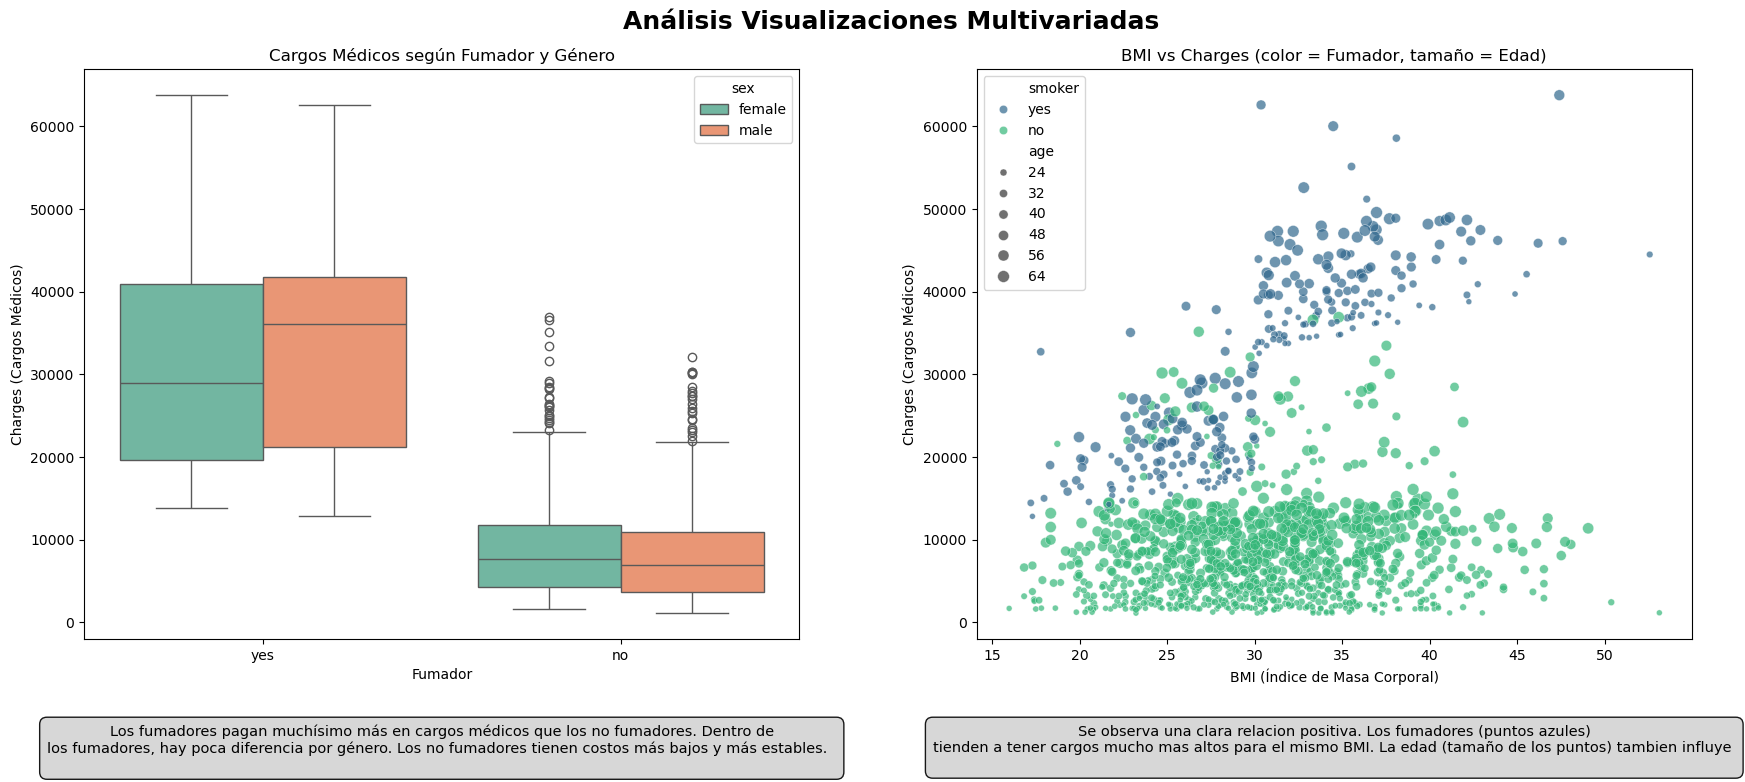

In [263]:

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Análisis Visualizaciones Multivariadas', fontsize=18, fontweight='bold')


sns.boxplot(
    x='smoker', 
    y='charges', 
    hue='sex', 
    data=df, 
    palette='Set2',
    ax=axes[0]
)
axes[0].set_title('Cargos Médicos según Fumador y Género')
axes[0].set_xlabel('Fumador')
axes[0].set_ylabel('Charges (Cargos Médicos)')
axes[0].text(0.5, -0.15,  
        "Los fumadores pagan muchísimo más en cargos médicos que los no fumadores. Dentro de\n"
        "los fumadores, hay poca diferencia por género. Los no fumadores tienen costos más bajos y más estables.  \n" ,
        transform=axes[0].transAxes, ha='center', va='top', fontsize=10.5, 
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.9))


sns.scatterplot(
    x='bmi', 
    y='charges',
    hue='smoker',
    size='age',
    data=df,
    alpha=0.7,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('BMI vs Charges (color = Fumador, tamaño = Edad)')
axes[1].set_xlabel('BMI (Índice de Masa Corporal)')
axes[1].set_ylabel('Charges (Cargos Médicos)')
axes[1].text(0.5, -0.15,  
        "Se observa una clara relacion positiva. Los fumadores (puntos azules)\n"
        "tienden a tener cargos mucho mas altos para el mismo BMI. La edad (tamaño de los puntos) tambien influye \n" ,
        transform=axes[1].transAxes, ha='center', va='top', fontsize=10.5, 
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.9))

plt.tight_layout()
plt.show()

- **2.2.- Codificar variables categóricas utilizando One-Hot Encoding.**


In [264]:
onehotencoder = OneHotEncoder(
    sparse_output=False,   # Devuelve array denso (más fácil de usar)
    drop=None,             # Sin eliminar ninguna categoría (full One-Hot)
    handle_unknown='ignore'
)

# Ajustar y transformar
enc_array = onehotencoder.fit_transform(df[colum_categoricas])

# Obtener nombres de las nuevas columnas
encoded_col = onehotencoder.get_feature_names_out(colum_categoricas)

# Crear DataFrame con las variables codificadas
df_encode = pd.DataFrame(enc_array, columns=encoded_col)

display(df_encode)

# Unir con el DataFrame original (manteniendo las numéricas)
df_enc = pd.concat([df.drop(columns=colum_categoricas), df_encode], axis=1)

display(df_enc)

,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
1333,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
1334,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1335,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1336,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,18,33.770,1,1725.55230,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,28,33.000,3,4449.46200,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,33,22.705,0,21984.47061,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,32,28.880,0,3866.85520,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
1334,18,31.920,0,2205.98080,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1335,18,36.850,0,1629.83350,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1336,21,25.800,0,2007.94500,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


- **2.3.- Escalar características numéricas utilizando StandardScaler.**



In [265]:
scaler = StandardScaler()

# Escalar solo las variables numéricas
df_enc[colum_numericas] = scaler.fit_transform(df_enc[colum_numericas])


display(df_enc)

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,-1.438764,-0.453320,-0.908614,0.298584,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-1.509965,0.509621,-0.078767,-0.953689,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,-0.797954,0.383307,1.580926,-0.728675,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,-0.441948,-1.305531,-0.908614,0.719843,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,-0.513149,-0.292556,-0.908614,-0.776802,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.768473,0.050297,1.580926,-0.220551,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
1334,-1.509965,0.206139,-0.908614,-0.914002,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1335,-1.509965,1.014878,-0.908614,-0.961596,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1336,-1.296362,-0.797813,-0.908614,-0.930362,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


### 3.- Implementación de Modelos de Clasificación:
- **3.1.-  Entrenar y evaluar al menos tres modelos de clasificación diferentes: Regresión Logística, K-Nearest Neighbors (KNN), y Árbol de Decisión.**


In [266]:

numerical_cols = ['age', 'bmi', 'children']

X = df.drop(['charges'], axis=1)
y = df['charges']


preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),colum_categoricas)
], verbose_feature_names_out=False)   # Limpia los nombres


models = {

    'KNN': KNeighborsRegressor(n_neighbors=5),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'LGBM': LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
}

results = []
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    results.append({
        'Modelo': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R²': r2_score(y_test, y_pred)
    })

# Los resultados
results_df = pd.DataFrame(results).round(4)
print(results_df.sort_values(by='R²', ascending=False))


         Modelo        MAE       RMSE      R²
2          LGBM  2608.6768  4562.3479  0.8659
1  RandomForest  2543.9758  4567.7751  0.8656
0           KNN  3891.0525  6803.3675  0.7019


c:\Users\lquel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


- **3.2.- Utilizar validación cruzada para evaluar el rendimiento inicial de los modelos.**

In [267]:
# Eliminar filas con nulos para correlación
df_cod  = df_enc.copy()
df_cod = df_cod.dropna()

# Matriz de correlación
correlacion = df_cod.corr()

# Filtrar características altamente correlacionadas con la variable objetivo mayor a 0.5
objetivo_corr = abs(correlacion['charges'])
columnas_relevantes = objetivo_corr[objetivo_corr > 0.5]

X = df_cod.drop(columns=['charges'])
y = df_cod['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [5, 10, None],
    'min_samples_leaf': [1, 2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid, cv=5, scoring='r2', n_jobs=-1
).fit(X_train, y_train)

print(f'Combinaciones probadas: {3*3*3} × 5 folds = 135 entrenamientos')
print(f'Mejores hiperparámetros: {grid.best_params_}')
print(f'R² en test:              {grid.score(X_test, y_test):.4f}')


modelos = {

    'KNN':     make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=10)),
    'RF':      RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42),
    'LGBM': LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
}

scores = {}
for nombre, m in modelos.items():
    m.fit(X_train, y_train); scores[nombre] = r2_score(y_test, m.predict(X_test))
tabla = pd.Series(scores).sort_values(ascending=False)
print('Benchmark:'); print(tabla.round(4))



Combinaciones probadas: 27 × 5 folds = 135 entrenamientos
Mejores hiperparámetros: {'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 100}
R² en test:              0.8779
Benchmark:
RF      0.8637
LGBM    0.8636
KNN     0.7994
dtype: float64


### 4.- Optimización de Hiperparámetros:
- **4.1.- Implementar GridSearchCV para optimizar los hiperparámetros de los modelos seleccionados.**


In [268]:

scores = {}
for nombre, m in modelos.items():
    m.fit(X_train, y_train); scores[nombre] = r2_score(y_test, m.predict(X_test))
tabla2 = pd.Series(scores).sort_values(ascending=False)
print('Benchmark:'); print(tabla2.round(4))


# Tuning del ganador (asumimos RF)
grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {'n_estimators': [100, 200], 'max_depth': [10, 15, None]},
    cv=3, scoring='r2', n_jobs=-1
).fit(X_train, y_train)
print(f'\nMejor RF tuned: {grid.best_params_}')
print(f'R² sin tuning: {tabla2["RF"]:.4f}')
print(f'R² con tuning: {grid.score(X_test, y_test):.4f}')


Benchmark:
RF      0.8637
LGBM    0.8636
KNN     0.7994
dtype: float64

Mejor RF tuned: {'max_depth': 10, 'n_estimators': 200}
R² sin tuning: 0.8637
R² con tuning: 0.8643


- **4.2.- Implementar RandomizedSearchCV como método alternativo de optimización.**

In [269]:


# Eliminar filas con nulos para correlación
df_cod  = df_enc.copy()
df_cod = df_cod.dropna()

# Matriz de correlación
correlacion = df_cod.corr()

# Filtrar características altamente correlacionadas con la variable objetivo mayor a 0.5
objetivo_corr = abs(correlacion['charges'])
columnas_relevantes = objetivo_corr[objetivo_corr > 0.5]

X = df_cod.drop(columns=['charges'])
y = df_cod['charges']# Preprocesamiento
categorical_cols = ['sex', 'smoker', 'region']
numerical_cols = ['age', 'bmi', 'children']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(random_state=42))
])

param_dist = {
    'model__alpha': np.logspace(-3, 3, 10),      # Equivalente a 'C' en regresión
    'model__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
    'model__max_iter': [1000, 2000, 5000]
}


random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("RandomizedSearchCV")
random_search.fit(X_train, y_train)



print(f"\nMejor R² en Validación Cruzada (CV): {random_search.best_score_:.4f}")

# Evaluación final
y_pred = random_search.predict(X_test)
print(f"R² en conjunto de Test: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

RandomizedSearchCV
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Mejor R² en Validación Cruzada (CV): 0.7331
R² en conjunto de Test: 0.7835
MAE: 4186.74
RMSE: 5798.17



- **4.3.- Comparar los resultados de GridSearchCV y RandomizedSearchCV para los modelos optimizados.**

In [270]:
categorical_cols = ['sex', 'smoker', 'region']
numerical_cols = ['age', 'bmi', 'children']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pipeline base
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

# ====================== 1. RANDOMIZEDSEARCHCV ======================
param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 15, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,          # Número de combinaciones aleatorias
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)


random_search.fit(X_train, y_train)


param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 15],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("\n🚀 Ejecutando GridSearchCV...")
grid_search.fit(X_train, y_train)


print("\n")
print(" comparando GRIDSEARCHCV vs RANDOMIZEDSEARCHCV")
print("\n")

results = {
    'Método': ['GridSearchCV', 'RandomizedSearchCV'],
    'Mejor R² (CV)': [grid_search.best_score_, random_search.best_score_],
    'R² en Test': [
        r2_score(y_test, grid_search.predict(X_test)),
        r2_score(y_test, random_search.predict(X_test))
    ],
    'MAE': [
        mean_absolute_error(y_test, grid_search.predict(X_test)),
        mean_absolute_error(y_test, random_search.predict(X_test))
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, grid_search.predict(X_test))),
        np.sqrt(mean_squared_error(y_test, random_search.predict(X_test)))
    ],
    'Mejores Parámetros': [grid_search.best_params_, random_search.best_params_]
}

comparison_df = pd.DataFrame(results)
display(comparison_df.round(4))

# Ganador
best_method = comparison_df.loc[comparison_df['R² en Test'].idxmax(), 'Método']
print(f"\n🏆 Mejor método según R² en Test: **{best_method}**")


Fitting 5 folds for each of 20 candidates, totalling 100 fits

🚀 Ejecutando GridSearchCV...
Fitting 5 folds for each of 24 candidates, totalling 120 fits


 comparando GRIDSEARCHCV vs RANDOMIZEDSEARCHCV




,Método,Mejor R² (CV),R² en Test,MAE,RMSE,Mejores Parámetros
0,GridSearchCV,0.8360,0.8745,2470.7447,4414.6320,"{'model__max_depth': 10, 'model__min_samples_l..."
1,RandomizedSearchCV,0.8406,0.8775,2479.9160,4361.5122,"{'model__n_estimators': 200, 'model__min_sampl..."



🏆 Mejor método según R² en Test: **RandomizedSearchCV**


### 5.- Evaluación de Modelos:
- **5.1.- Evaluar los modelos optimizados utilizando métricas de rendimiento como exactitud, precisión, recall, F1-Score y ROC-AUC.**



 Tabla de rendimientos
              Accuracy  Precision  Recall      F1     AUC
Modelo                                                   
KNN             0.8731     0.9261  0.8109  0.8647  0.9387
RandomForest    0.9453     0.9686  0.9204  0.9439  0.9601
LGBM            0.9353     0.9581  0.9104  0.9337  0.9561


c:\Users\lquel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\lquel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


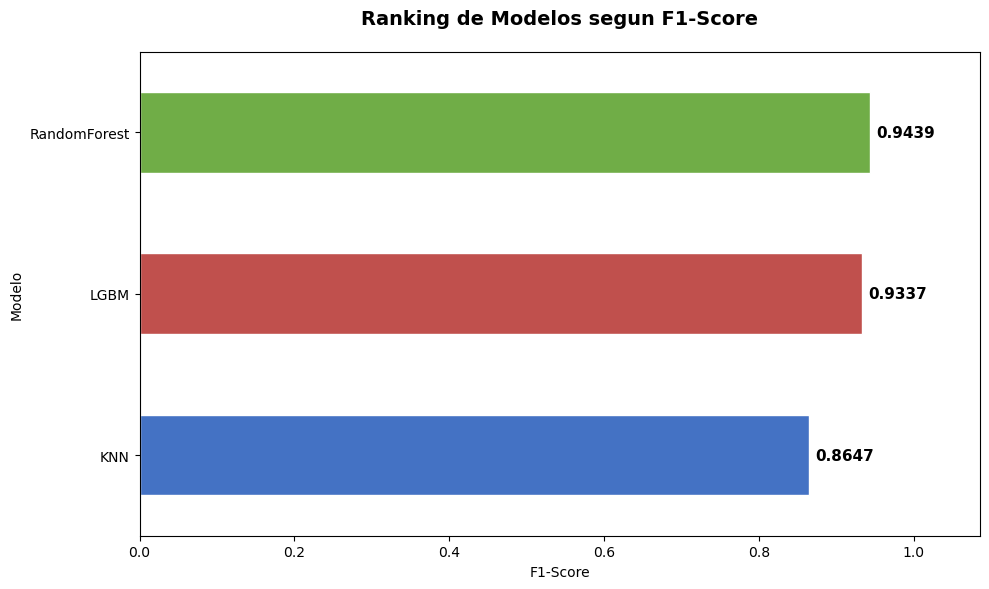


 GANADOR segun F1-Score: RandomForest con F1 = 0.9439


In [271]:
# Crear variable objetivo binaria para clasificación
# HighCharges = 1 si los cargos están por encima de la mediana
df['HighCharges'] = (df['charges'] > df['charges'].median()).astype(int)

# ====================== PREPROCESAMIENTO ======================
categorical_cols = ['sex', 'smoker', 'region']
numerical_cols = ['age', 'bmi', 'children']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='drop',  # eliminamos 'charges' original
    verbose_feature_names_out=False
)

# Features y target
X = df.drop(['charges', 'HighCharges'], axis=1)
y = df['HighCharges']

# División train/test (estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


# ====================== MODELOS DE CLASIFICACIÓN ======================
modelos = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'LGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
}
pipelines = {}
filas = []

for nombre, modelo in modelos.items():
    # Crear pipeline con preprocesamiento + modelo
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', modelo)
    ])
    
    pipeline.fit(X_train, y_train)
    pipelines[nombre] = pipeline
    
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    filas.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba)
    })


tabla = pd.DataFrame(filas).set_index('Modelo').round(4)
print("\n Tabla de rendimientos")
print(tabla)


fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#4472C4', '#C0504D', '#70AD47']

tabla['F1'].sort_values().plot(kind='barh', color=colores, edgecolor='white', ax=ax)

for i, v in enumerate(tabla['F1'].sort_values()):
    ax.text(v + 0.008, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=11)

ax.set_title('Ranking de Modelos segun F1-Score', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('F1-Score')
ax.set_xlim(0, max(tabla['F1']) * 1.15)
plt.tight_layout()
plt.show()

# Ganador
ganador = tabla['F1'].idxmax()
print(f"\n GANADOR segun F1-Score: {ganador} con F1 = {tabla.loc[ganador, 'F1']:.4f}")

- **5.2.- Generar y analizar la matriz de confusión para los modelos optimizados.**


Top 2 modelos según F1-Score: ['RandomForest', 'LGBM']


c:\Users\lquel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


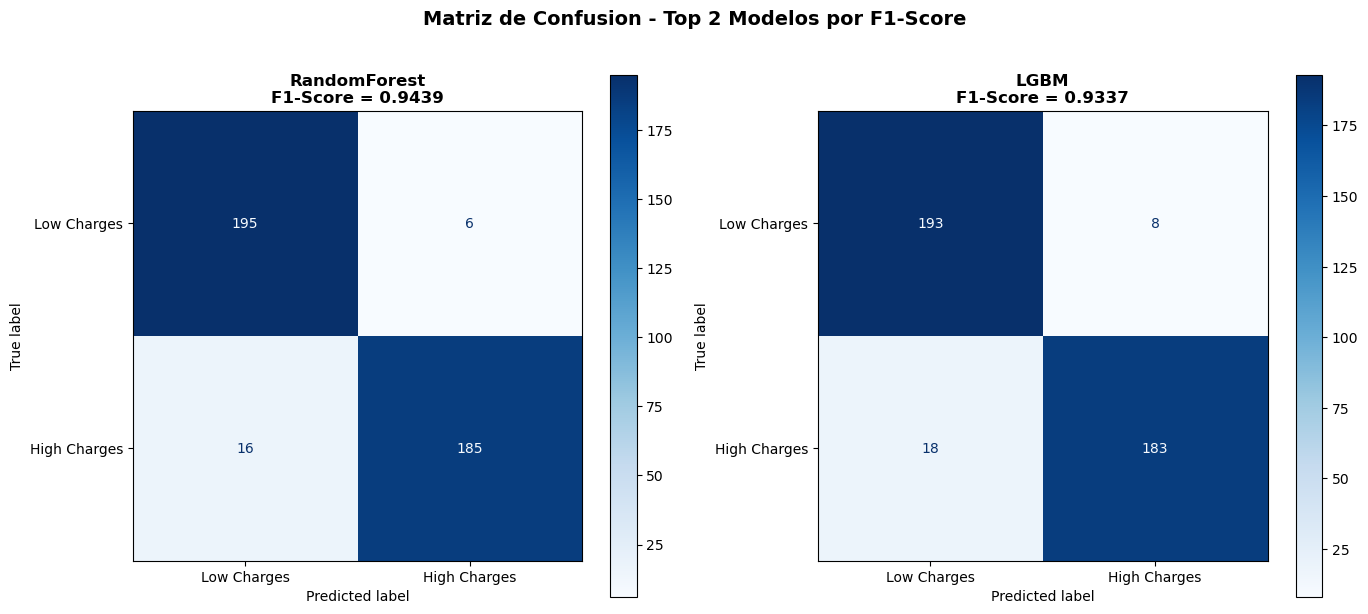

In [272]:

ranking_f1 = tabla['F1'].sort_values(ascending=False).head(2).index.tolist()

print("Top 2 modelos según F1-Score:", ranking_f1)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, nombre in enumerate(ranking_f1):
    # Crear pipeline nuevamente y entrenar (forma más segura)
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', modelos[nombre])
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Matriz de Confusión
    ConfusionMatrixDisplay.from_predictions(
        y_test, 
        y_pred, 
        ax=axes[i], 
        cmap='Blues',
        display_labels=['Low Charges', 'High Charges'],
        normalize=None
    )
    
    axes[i].set_title(f'{nombre}\nF1-Score = {tabla.loc[nombre, "F1"]:.4f}', 
                      fontweight='bold', fontsize=12)

plt.suptitle('Matriz de Confusion - Top 2 Modelos por F1-Score', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

plt.show()

### Interpretación en términos de negocio :

- **TN = 195  Identifica correctamente a las personas con cargos bajos. Muy buen resultado**
- **TP = 185  De los 201 casos reales de HighCharges, el modelo detectó correctamente 185. Está capturando el 91% de los clientes de alto riesgo.**
- **FP = 6  Etiquetó como "alto riesgo" a 6 personas que en realidad generaron cargos bajos.**
- **FN = 16  Aquí está el principal problema.Hay 16 personas de alto riesgo que el modelo clasificó como bajo riesgo.**

- **5.3.- Crear y visualizar la curva ROC para evaluar la capacidad del modelo para distinguir entre clases.**

c:\Users\lquel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


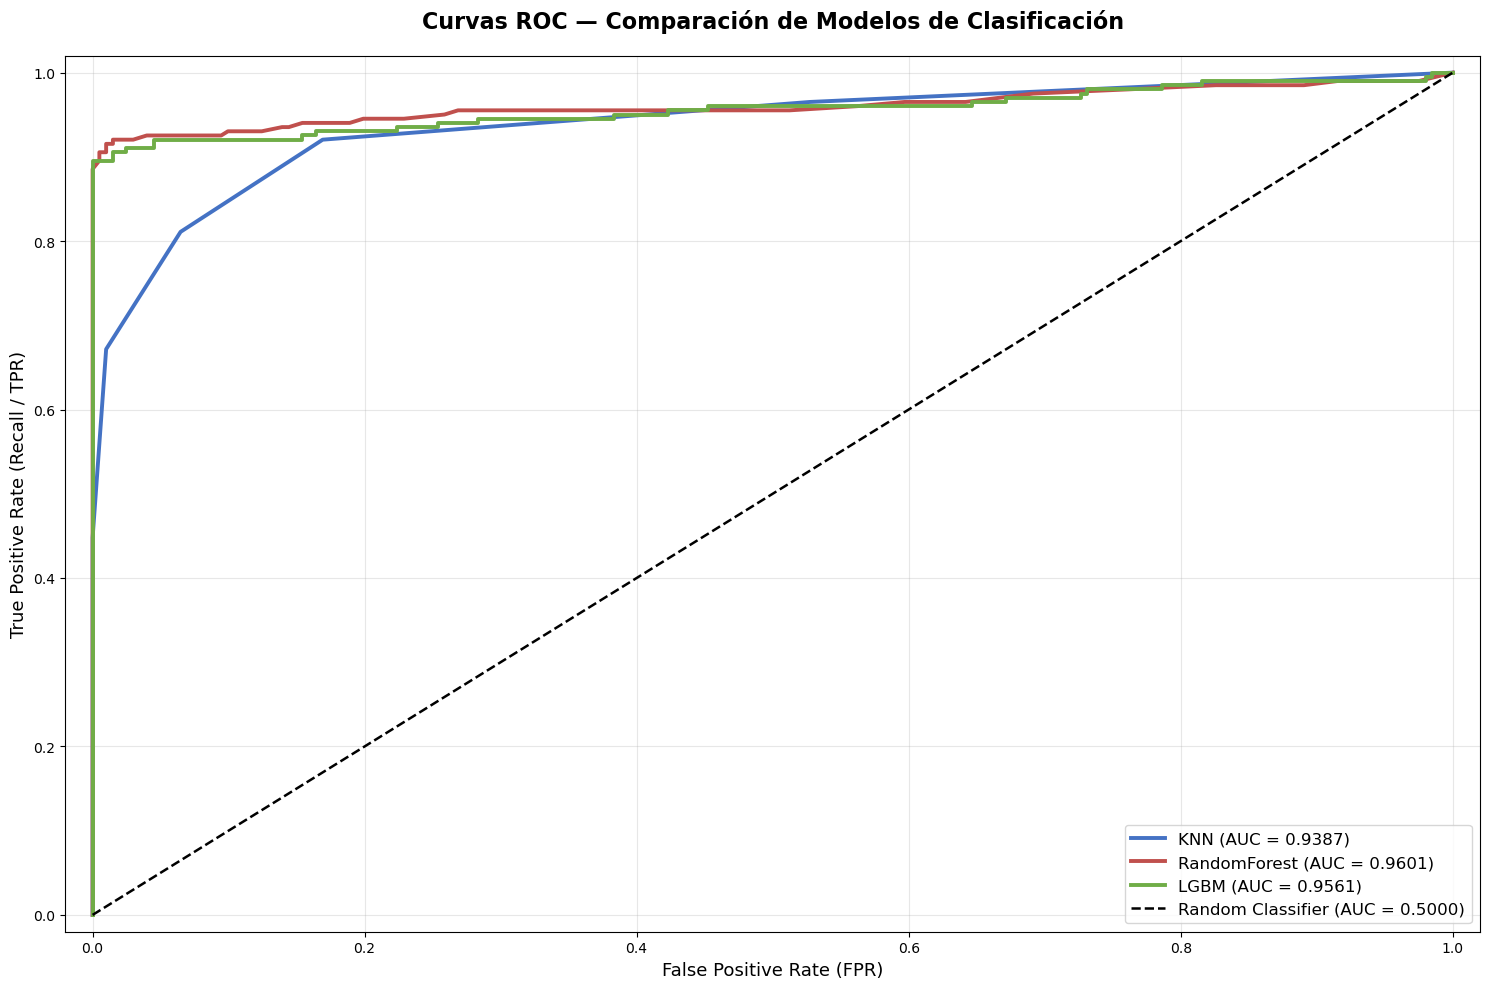

In [273]:

fig, ax = plt.subplots(figsize=(15, 10))

# Colores para cada modelo
colores_roc = {
    'KNN': '#4472C4',
    'RandomForest': '#C0504D',
    'LGBM': '#70AD47'
}

for nombre, pipeline in pipelines.items():          # Usamos los pipelines guardados
    # Obtener probabilidades
    proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Calcular curva ROC
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    
    # Graficar
    ax.plot(fpr, tpr,
            color=colores_roc.get(nombre, '#ED7D31'),
            linewidth=2.8,
            label=f'{nombre} (AUC = {auc:.4f})')

# Línea de referencia (clasificador aleatorio)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.8, label='Random Classifier (AUC = 0.5000)')

# Personalización
ax.set_xlabel('False Positive Rate (FPR)', fontsize=13)
ax.set_ylabel('True Positive Rate (Recall / TPR)', fontsize=13)
ax.set_title('Curvas ROC — Comparación de Modelos de Clasificación',
             fontsize=16, fontweight='bold', pad=20)

ax.legend(loc='lower right', fontsize=12)
ax.grid(True, alpha=0.3)

# Ajustes finales
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
plt.tight_layout()
plt.show()

### Analisis de Curva Roc
**el modelo Random Forest es superior a los demas con un AUC > 0.95. este modelo nos permitira separar a los clientes que generan cargos médicos. Aunque el modelo es muy bueno en general, estamos c apturando solo alrededor del 82% de los casos de HighCharges. El otro 18% se nos escapa. Para la compañía de seguros esto se traduce en subestimación del riesgo. Estos clientes “falsos negativos” pueden generar pérdidas importantes porque no se les asigna el perfil de riesgo correcto. Si el suscriptor tuviera que revisar manualmente todos los casos para asegurarse de no perderse ninguno, el modelo no le habría ahorrado tanto trabajo como podría.**